Proyecto INF497
--Integrantes: José Manzano y Manuel Silva

Configuración inicial:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point

sns.set_theme(style="whitegrid")

Recreación del Análisis Visual Exploratorio (Macro)

C:\Users\Jmanzanom\AppData\Local\Temp\ipykernel_30696\1493200620.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df_macro, x='Región', y='Cantidad de Campamentos', palette=['#428bca', '#d9534f'], edgecolor='black')
C:\Users\Jmanzanom\AppData\Local\Temp\ipykernel_30696\1493200620.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df_macro, x='Región', y='Cantidad de Familias', palette=['#428bca', '#d9534f'], edgecolor='black')


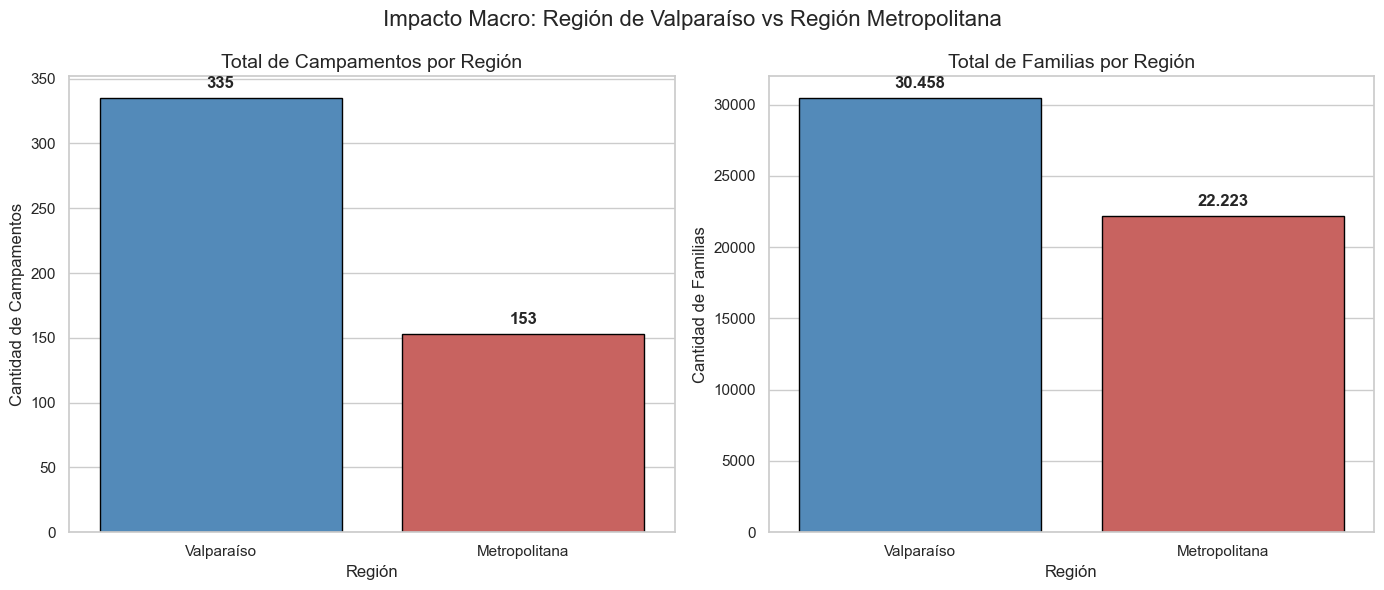

In [8]:
datos_macro = {
    'Región': ['Valparaíso', 'Metropolitana'],
    'Cantidad de Campamentos': [335, 153],
    'Cantidad de Familias': [30458, 22223]
}
df_macro = pd.DataFrame(datos_macro)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impacto Macro: Región de Valparaíso vs Región Metropolitana', fontsize=16)

#Total de Campamentos
sns.barplot(ax=axes[0], data=df_macro, x='Región', y='Cantidad de Campamentos', palette=['#428bca', '#d9534f'], edgecolor='black')
axes[0].set_title('Total de Campamentos por Región', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

#Total de Familias
sns.barplot(ax=axes[1], data=df_macro, x='Región', y='Cantidad de Familias', palette=['#428bca', '#d9534f'], edgecolor='black')
axes[1].set_title('Total de Familias por Región', fontsize=14)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}'.replace(',', '.'), (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [9]:
import xml.etree.ElementTree as ET
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon

def cargar_kml_puro_python(ruta_archivo):
    #Parsear
    tree = ET.parse(ruta_archivo)
    root = tree.getroot()
    
    namespace = ""
    if root.tag.startswith("{"):
        namespace = root.tag.split("}")[0] + "}"
        
    elementos = []
    
    #Placemarks
    for placemark in root.findall(f".//{namespace}Placemark"):
        nombre_nodo = placemark.find(f"{namespace}name")
        desc_nodo = placemark.find(f"{namespace}description")
        
        nombre = nombre_nodo.text if nombre_nodo is not None else "Sin Nombre"
        descripcion = desc_nodo.text if desc_nodo is not None else ""
        
        poligono_nodo = placemark.find(f".//{namespace}Polygon//{namespace}coordinates")
        if poligono_nodo is not None and poligono_nodo.text:
            coordenadas_txt = poligono_nodo.text.strip()
            puntos_poligono = []
            for coord_str in coordenadas_txt.split():
                partes = coord_str.split(',')
                if len(partes) >= 2:
                    puntos_poligono.append((float(partes[0]), float(partes[1])))
            if len(puntos_poligono) >= 3:
                elementos.append({
                    'Name': nombre,
                    'Description': descripcion,
                    'geometry': Polygon(puntos_poligono)
                })

    #Convertir la lista de diccionarios en un GeoDataFrame espacial
    gdf = gpd.GeoDataFrame(elementos, crs="EPSG:4326")
    return gdf
ruta_kml = 'doc.kml'
gdf_campamentos = cargar_kml_puro_python(ruta_kml)

print(f"Se cargaron {len(gdf_campamentos)} elementos desde el archivo KML.")
display(gdf_campamentos.head())

Se cargaron 1428 elementos desde el archivo KML.


,Name,Description,geometry
0,Lomas de Ramón Ángel Jara,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.40614 -33.07103, -71.40563 -33.0..."
1,Pompeya Sur,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.47948 -33.06025, -71.47795 -33.0..."
2,Mirador troncal sur,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.46351 -33.05897, -71.46406 -33.0..."
3,Comunidad Antumapu,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.40487 -33.07149, -71.40482 -33.0..."
4,Nueva Toltén,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","POLYGON ((-71.36994 -33.068, -71.37026 -33.067..."


In [10]:
lugar = "Viña del Mar, Región de Valparaíso, Chile"

#Tags de OSM para los servicios esenciales
tags_servicios = {
    'amenity': ['hospital', 'clinic', 'school', 'kindergarten'],
    'public_transport': ['stop_position', 'platform'],
    'highway': ['bus_stop']
}

servicios_osm = ox.features_from_place(lugar, tags=tags_servicios)

# Filtrar solo los puntos, si es un polígono, extraemos su centroide (el centro exacto del edificio)
servicios_osm['geometry'] = servicios_osm['geometry'].apply(
    lambda geom: geom.centroid if geom.type == 'Polygon' else geom
)
servicios_puntos = servicios_osm[servicios_osm.geometry.type == 'Point']

print(f"Se extrajeron {len(servicios_puntos)} puntos de servicios.")

Se extrajeron 654 puntos de servicios.


C:\Users\Jmanzanom\AppData\Local\Temp\ipykernel_30696\4165092422.py:14: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  lambda geom: geom.centroid if geom.type == 'Polygon' else geom


Para medir distancias reales en metros proyectamos ambos mapas al sistema UTM de Chile (Zona 19S, que corresponde al código EPSG:32719).

In [11]:
gdf_campamentos_utm = gdf_campamentos.to_crs(epsg=32719)
servicios_puntos_utm = servicios_puntos.to_crs(epsg=32719)

#Funcion para calcular la distancia mínima
def calcular_distancia_minima(punto, gdf_destinos):
    # Calcula la distancia desde un punto a todos los destinos
    distancias = gdf_destinos.geometry.distance(punto)
    # Retorna la distancia mínima encontrada
    return distancias.min()

#Buscar solo de "Viña del Mar"
gdf_campamentos_vina = gdf_campamentos[
    gdf_campamentos['Description'].str.contains("Viña del Mar", case=False, na=False)
].copy()

print(f"Total de campamentos en Viña del Mar encontrados: {len(gdf_campamentos_vina)}")

# 2. Proyectar a UTM (metros) solo los de Viña del Mar
gdf_campamentos_vina_utm = gdf_campamentos_vina.to_crs(epsg=32719)
# (Asegúrate de que servicios_puntos_utm ya esté proyectado de la celda anterior)

gdf_campamentos_vina_utm['Distancia_Minima_Servicios_m'] = gdf_campamentos_vina_utm.geometry.apply(
    lambda geom: calcular_distancia_minima(geom, servicios_puntos_utm)
)

# 4. Mostrar los resultados reales
resultados_vina = gdf_campamentos_vina_utm.sort_values(by='Distancia_Minima_Servicios_m', ascending=False)

print("\nTop 5 Campamentos más aislados en Viña del Mar:")
display(resultados_vina[['Name', 'Distancia_Minima_Servicios_m']].head())

Total de campamentos en Viña del Mar encontrados: 114

Top 5 Campamentos más aislados en Viña del Mar:


,Name,Distancia_Minima_Servicios_m
242,Esperanza 2011,1144.969818
218,Villa Vista Hermosa,748.177249
233,Chile despertó,562.173744
237,Villa Bendicion,560.085508
221,Villa Jorge Kaplan,508.764893


Esta celda calcula el comportamiento numérico de la exclusión en los campamentos de Viña del Mar.

In [18]:
#Estadisticas descriptivas
print("Estadísticas Descriptivas de la Variable de Interés:")
display(resultados_vina['Distancia_Minima_Servicios_m'].describe())

Q50 = resultados_vina['Distancia_Minima_Servicios_m'].median()
print(f"\nEl 50% de los campamentos está a más de {Q50:.2f} metros de un servicio esencial.")

Estadísticas Descriptivas de la Variable de Interés:


count     114.000000
mean      228.909076
std       170.796837
min         0.000000
25%       111.995921
50%       183.850498
75%       309.687344
max      1144.969818
Name: Distancia_Minima_Servicios_m, dtype: float64


El 50% de los campamentos está a más de 183.85 metros de un servicio esencial.


Utilizaremos el método de Fisher-Jenks (o Natural Breaks), el cual es metodológicamente ideal para este caso porque agrupa los campamentos reduciendo la varianza interna y maximizando las diferencias entre grupos (identifica brechas reales de aislamiento).

In [ ]:
import geopandas as gpd

gdf_comunas = gpd.read_file('COMUNA_C17.shp')
gdf_comunas_utm = gdf_comunas.to_crs(resultados_vina.crs)

if len(gdf_comunas_utm) == 1:
    gdf_limite_vina_utm = gdf_comunas_utm.copy()
    print("El archivo contenía un único polígono. Usándolo como fondo de Viña del Mar.")
else:
    # Hacemos un join espacial para ver qué polígono del mapa contiene a los campamentos
    interseccion = gpd.sjoin(gdf_comunas_utm, resultados_vina, predicate='intersects')
    
    id_vina = interseccion.index.value_counts().idxmax()
    gdf_limite_vina_utm = gdf_comunas_utm.loc[[id_vina]].copy()
    print("Polígono de Viña del Mar identificado geográficamente mediante intersección.")

Polígono de Viña del Mar identificado geográficamente mediante intersección.


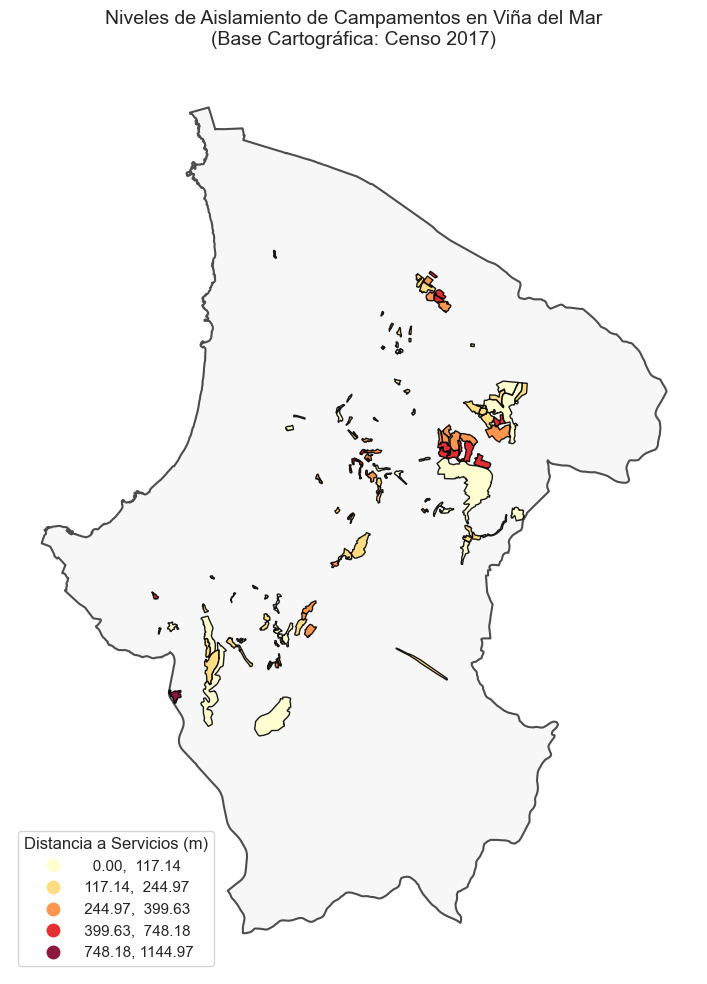

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

#Fondo
gdf_limite_vina_utm.plot(
    ax=ax, 
    facecolor='#f7f7f7',
    edgecolor='#4d4d4d',
    linewidth=1.5, 
    zorder=1,
    label='Límite Comunal'
)

#Campamentos
resultados_vina.plot(
    column='Distancia_Minima_Servicios_m', 
    cmap='YlOrRd', 
    scheme='FisherJenks',  
    k=5,                   
    legend=True, 
    ax=ax,
    legend_kwds={'title': "Distancia a Servicios (m)", 'loc': 'lower left'},
    markersize=45,
    edgecolor='black',
    alpha=0.9,
    zorder=2
)

ax.set_title("Niveles de Aislamiento de Campamentos en Viña del Mar\n(Base Cartográfica: Censo 2017)", fontsize=14, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('mapa_aislamiento_vina.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

--- Análisis de Autocorrelación Espacial Global ---
Índice de Moran (I): 0.2809
Valor p esperado: 0.0010
Z-Score: 5.55
Resultado: Autocorrelación espacial POSITIVA significativa. Los campamentos con niveles de aislamiento similares tienden a agruparse en el espacio.


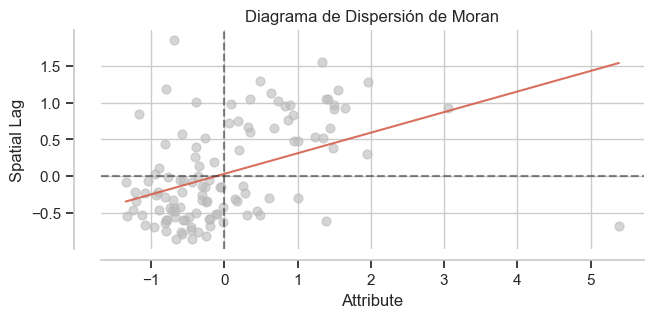

In [ ]:
import libpysal
from esda.moran import Moran
from splot.esda import moran_scatterplot

w = libpysal.weights.KNN.from_dataframe(resultados_vina, k=5)
w.transform = 'R'


y = resultados_vina['Distancia_Minima_Servicios_m'].values

#Moran Global
moran = Moran(y, w)

print("--- Análisis de Autocorrelación Espacial Global ---")
print(f"Índice de Moran (I): {moran.I:.4f}")
print(f"Valor p esperado: {moran.p_sim:.4f}")
print(f"Z-Score: {moran.z_sim:.2f}")

#Interpretación
if moran.p_sim < 0.05:
    if moran.I > 0:
        print("Resultado: Autocorrelación espacial POSITIVA significativa. Los campamentos con niveles de aislamiento similares tienden a agruparse en el espacio.")
    else:
        print("Resultado: Autocorrelación espacial NEGATIVA significativa (dispersión).")
else:
    print("Resultado: No se rechaza la hipótesis nula. La distribución del aislamiento es espacialmente aleatoria.")

#Dispersión de Moran
fig, ax = moran_scatterplot(moran, aspect_equal=True)
plt.title("Diagrama de Dispersión de Moran")
plt.savefig('mapa_lisa_clusters.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import numpy as np
import statsmodels.api as sm
from pysal.model import spreg

y_reg = resultados_vina['Distancia_Minima_Servicios_m'].values

X_reg = np.ones((len(y_reg), 1)) 

#IMPLEMENTACIÓN PARCIAL
ols_diagnostico = spreg.OLS(y_reg, X_reg, w=w, name_y='Distancia_Servicios', name_x=['Constante'])
print(ols_diagnostico.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Distancia_Servicios                Number of Observations:         114
Mean dependent var  :    228.9091                Number of Variables   :           1
S.D. dependent var  :    170.7968                Degrees of Freedom    :         113
R-squared           :     -0.0000
Adjusted R-squared  :     -0.0000
Sum squared residual: 3.29639e+06                F-statistic           :         inf
Sigma-square        :   29171.560                Prob(F-statistic)     :         nan
S.E. of regression  :     170.797                Log likelihood        :    -747.271
Sigma-square ML     :   28915.669                Akaike info criterion :    1496.542
S.E of regression ML:    170.0461                Schwarz criterion     :    1499.278

----------

c:\Users\Jmanzanom\AppData\Local\Programs\Python\Python310\lib\site-packages\spreg\diagnostics.py:114: RuntimeWarning: divide by zero encountered in scalar divide
  fStat = (U / r) / (utu / (n - k))
